# Kalman Filter/Smoother

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

asset = "morpho"

# Load dataset (Replace this with your actual CSV file)
df_1 = pd.read_csv(f"/Users/valter.rebelo/MissionControl/micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

df_2 = pd.read_csv(f"/Users/valter.rebelo/MissionControl/micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

data = pd.merge(df_1, df_2[['total_volume']], on='date', how='inner')

#data = data[data.index > '2013-12-31']

data.rename(columns={'total_volume': 'Volume',
                     'open': 'Open',
                     'high': 'High',
                     'low': 'Low',
                     'close': 'Close'}, inplace=True)

data.index.name = 'Date'

data 

,Open,High,Low,Close,Volume
Date,,,,,
2024-11-19,NaN,NaN,NaN,NaN,1.215206e+03
2024-11-20,NaN,NaN,NaN,NaN,1.215206e+03
2024-11-21,1.280000,1.30,1.250000,1.270000,2.441717e+08
2024-11-22,1.310000,3.11,0.845599,0.978815,1.297174e+08
2024-11-23,0.972387,1.19,0.883336,0.947904,5.838092e+07
...,...,...,...,...,...
2025-02-12,2.000000,2.20,1.880000,1.910000,3.833064e+07
2025-02-13,1.920000,2.06,1.850000,2.000000,3.001767e+07
2025-02-14,2.010000,2.06,1.910000,2.050000,4.865463e+07


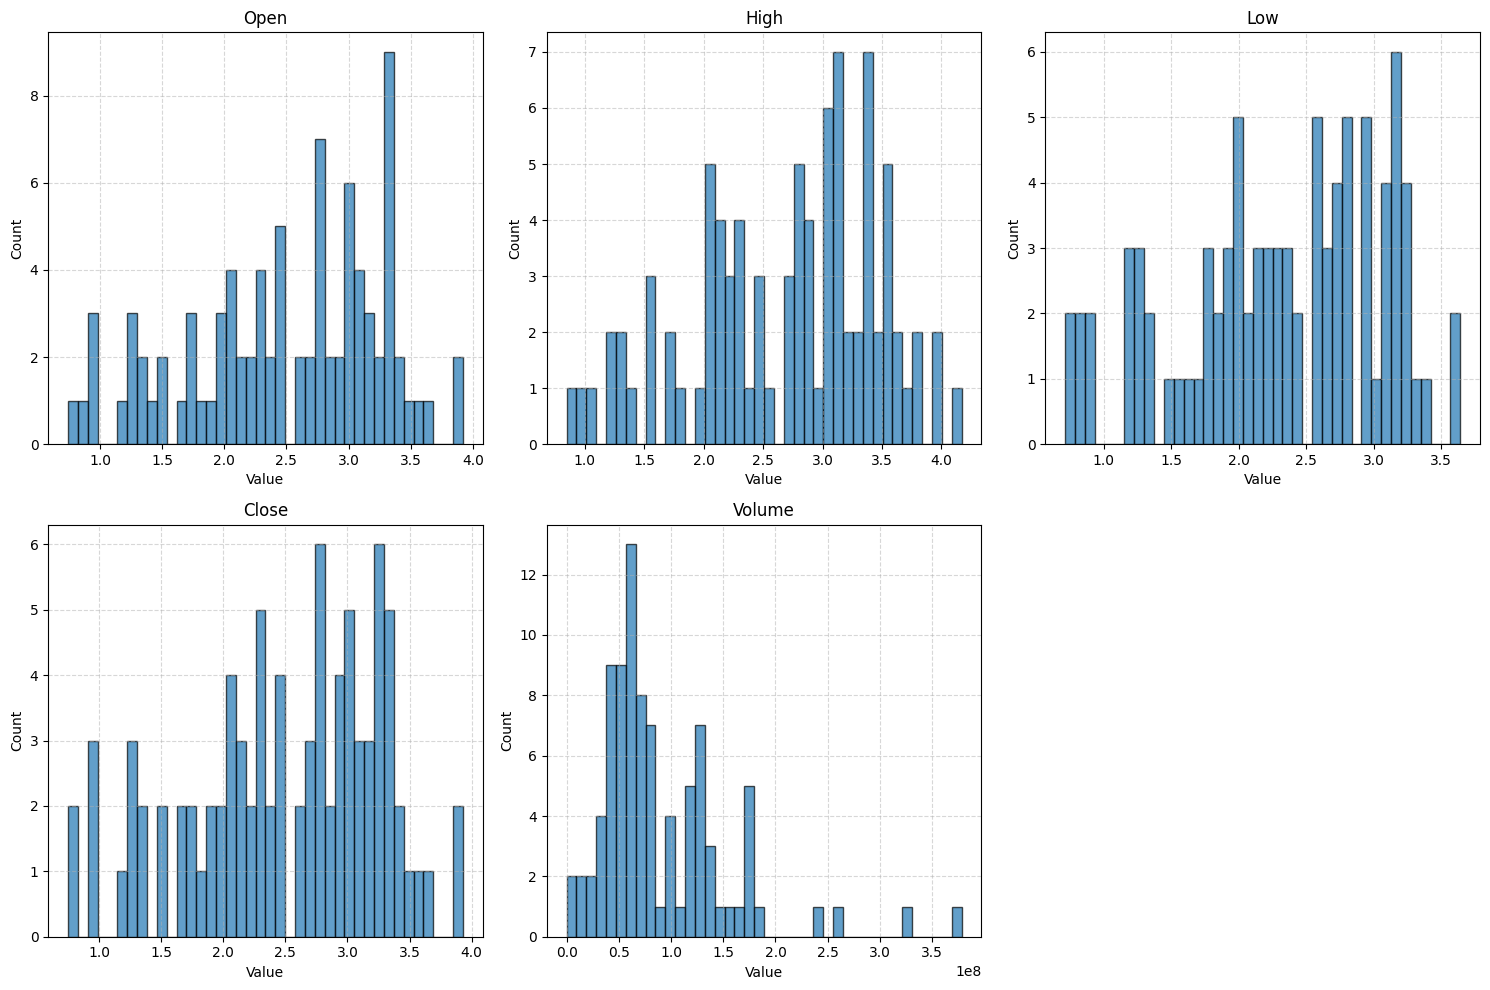

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_distributions(df, feature_cols=None, bins=50, figsize=(15, 10)):
    """
    Plots the distribution (histograms) of specified feature columns in a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing your features.
    feature_cols : list of str, optional
        List of columns to plot. If None, attempts to plot all numeric columns 
        except non-feature columns (e.g., 'symbol', 'interval', 'Date').
    bins : int, optional
        Number of histogram bins. Default 50.
    figsize : tuple, optional
        Figure size for the overall plot. Default (15, 10).
    
    Returns
    -------
    None (Displays a Matplotlib figure of histograms)
    """
    
    # If user does not specify feature columns, attempt to infer from numeric columns
    if feature_cols is None:
        # Exclude any known non-feature columns
        exclude_cols = {'symbol', 'interval', 'Date'}
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                        if col not in exclude_cols]
    
    n_features = len(feature_cols)
    
    # Decide on subplot grid (approx square layout)
    n_cols = int(np.ceil(np.sqrt(n_features)))
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to easily iterate even if there's only 1 row
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        # Drop NaN to avoid issues in hist
        valid_data = df[col].dropna()
        ax.hist(valid_data, bins=bins, edgecolor='k', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Count')
        ax.set_xlabel('Value')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


# Example usage:
# Assuming 'df' is your feature DataFrame:
# plot_feature_distributions(df)
# or specify columns explicitly:
plot_feature_distributions(data, feature_cols=data.columns, bins=40)

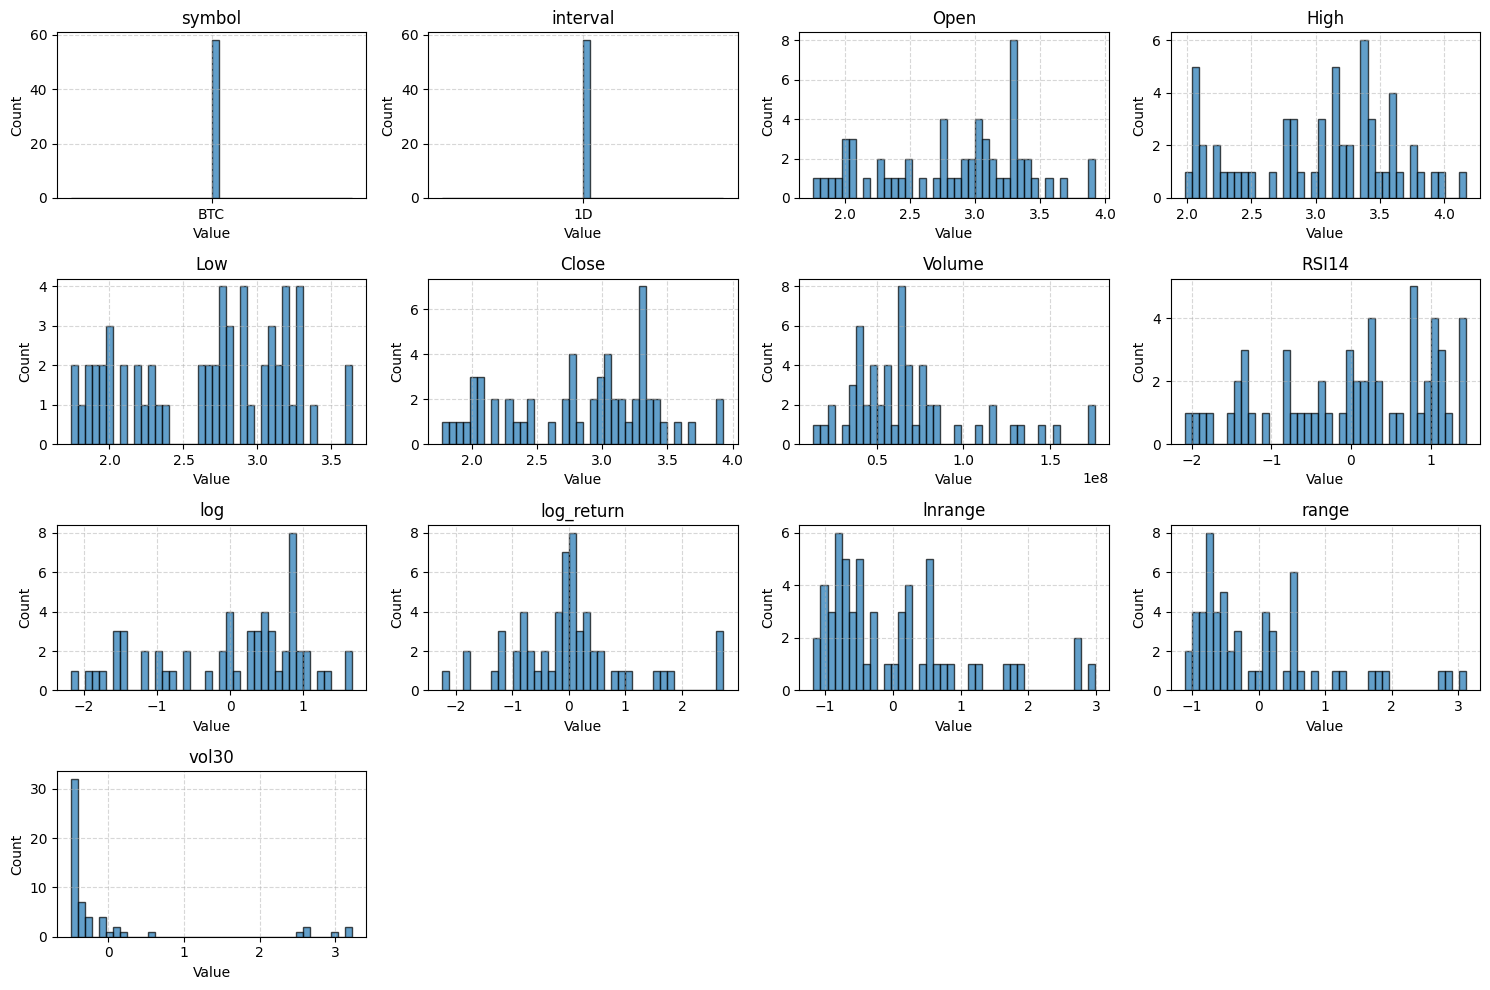

In [31]:
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler

data = data[['Open', 'High', 'Low', 'Close', 'Volume']]

#copy and structure
df = data.copy()

df['RSI14'] = ta.rsi(df['Close'], length=14)

# Basic log transformations
df['log'] = np.log(df['Close'])
df['log_return'] = df['log'].pct_change()
#df['log_return_30'] = df['log'].diff(periods=30)
#df['log_return_7'] = df['log'].diff(periods=7)
df['lnrange'] = np.log(df['High']/df['Low'])-1
#df['lnvolume'] = np.log(df['Volume'])
df['range'] = (df["High"] / df["Low"]) - 1

# Add Moving Averages (and their log transformations)
#df['MA30'] = df['Close'].rolling(window=30).mean()
#df['MA365'] = df['Close'].rolling(window=365).mean()
#df['lnMA30'] = np.log(df['MA30'])
#df['lnMA365'] = np.log(df['MA365'])


# Add Rolling Volatility (standard deviation of log returns)
df['vol30'] = df['log_return'].rolling(window=30).std()


# Drop any NaN values that might have been introduced
df.dropna(inplace=True)

scaler = StandardScaler()
features_to_scale = [
    
    'log', 'log_return', 'lnrange', 'range', 'RSI14', 'vol30'
]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


# Add symbol and interval columns
symbol = 'BTC'
interval = '1D'

df.insert(0, 'symbol', symbol.upper())
df.insert(1, 'interval', interval.upper())

plot_feature_distributions(df, feature_cols=df.columns, bins=40)

In [32]:
from pykalman import KalmanFilter 

kf = KalmanFilter(
    transition_matrices=[1],  # State transition matrix
    observation_matrices=[1],  # Observation matrix
    initial_state_mean=df['Close'].iloc[0],  # Initial state estimate
    initial_state_covariance=1,  # Initial state covariance
    observation_covariance=1,  # Observation noise covariance
    transition_covariance=0.01  # Process noise covariance (adjustable)
)

# Apply the Kalman filter
state_means, state_covariances = kf.filter(df['Close'].values)
df['kalman_close'] = state_means.flatten()
smoothed_state_means, smoothed_state_covariances = kf.smooth(df['kalman_close'].values)
df['kalman_smooth'] = smoothed_state_means.flatten()
df['close_kalman_diff'] = np.abs(df['Close'] - df['kalman_smooth'])
df['close_slope'] = df['Close'].diff(periods=7)
df['kalman_smooth_slope'] = df['kalman_smooth'].diff(periods=7)
df.dropna(inplace=True)
df


,symbol,interval,Open,High,Low,Close,Volume,RSI14,log,log_return,lnrange,range,vol30,kalman_close,kalman_smooth,close_kalman_diff,close_slope,kalman_smooth_slope
Date,,,,,,,,,,,,,,,,,,
2024-12-28,BTC,1D,2.91,3.06,2.81,3.02,6.411508e+07,0.994395,0.399475,0.295318,-0.657480,-0.647428,0.214334,2.760450,2.844887,0.175113,0.23,0.045600
2024-12-29,BTC,1D,3.01,3.15,2.77,3.04,4.096352e+07,1.020145,0.431331,0.049973,-0.001151,-0.033583,0.120577,2.795792,2.857414,0.182586,0.77,0.057941
2024-12-30,BTC,1D,3.02,3.07,2.81,2.84,8.332413e+07,0.610668,0.102889,-0.693419,-0.608054,-0.602121,0.125058,2.801099,2.870557,0.030557,0.58,0.069048
2024-12-31,BTC,1D,2.84,3.01,2.74,2.96,1.433508e+08,0.786581,0.302624,0.422629,-0.524900,-0.525563,-0.006512,2.819385,2.884394,0.075606,0.20,0.078063
2025-01-01,BTC,1D,2.97,3.61,2.91,3.48,6.203509e+07,1.434624,1.083718,1.634222,1.316814,1.282375,-0.033131,2.892829,2.898882,0.581118,0.69,0.085395
2025-01-02,BTC,1D,3.47,3.57,3.20,3.37,7.531459e+07,1.205263,0.928701,-0.301133,-0.291109,-0.308055,-0.034327,2.944401,2.913430,0.456570,0.31,0.090777
2025-01-03,BTC,1D,3.36,3.58,3.26,3.29,6.892629e+07,1.037447,0.812749,-0.234942,-0.530150,-0.530409,-0.066960,2.980900,2.927669,0.362331,0.36,0.094464
2025-01-04,BTC,1D,3.29,3.36,3.15,3.28,6.311966e+07,1.015595,0.798058,-0.044400,-0.970944,-0.931347,-0.069642,3.011895,2.941375,0.338625,0.26,0.096488
2025-01-05,BTC,1D,3.28,3.51,3.20,3.35,8.024611e+07,1.115182,0.899973,0.180610,-0.547880,-0.546762,-0.300169,3.046393,2.954376,0.395624,0.31,0.096962


In [33]:
def plot_kalman_results(df, start_date=None, end_date=None):
    """
    Plots the original close prices alongside Kalman filter and smoother results.
    Creates a continuous price line that changes color based on its position
    relative to the Kalman smooth line.
    """
    # Make a copy to avoid modifying original
    plot_df = df.copy()
    
    # Convert dates to datetime if they're strings
    if start_date:
        start_date = pd.to_datetime(start_date)
    if end_date:
        end_date = pd.to_datetime(end_date)
    
    # Filter data based on dates if provided
    if start_date:
        plot_df = plot_df[plot_df.index >= start_date]
    if end_date:
        plot_df = plot_df[plot_df.index <= end_date]
    
    plt.figure(figsize=(15, 8))
    
    # Plot price line segments with color changes
    for i in range(1, len(plot_df)):
        x = [plot_df.index[i-1], plot_df.index[i]]
        y = [plot_df['Close'].iloc[i-1], plot_df['Close'].iloc[i]]
        
        color = 'k' if plot_df['Close'].iloc[i] >= plot_df['kalman_close'].iloc[i] else 'r'
        plt.plot(x, y, color=color, linestyle='-', alpha=1)
    
    # Plot Kalman filter estimate
    plt.plot(plot_df.index, plot_df['kalman_close'], 'r-', 
             label='Kalman Filter', linewidth=1)
    
    # Add custom legend entries
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='k', linestyle='--', label='Price Above Kalman'),
        Line2D([0], [0], color='r', linestyle='--', label='Price Below Kalman'),
        Line2D([0], [0], color='r', linestyle='-', label='Kalman Filter')
    ]
    plt.legend(handles=custom_lines)
    
    plt.title('Asset Price with Kalman Filter')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid(True, alpha=0.3)
    plt.show()

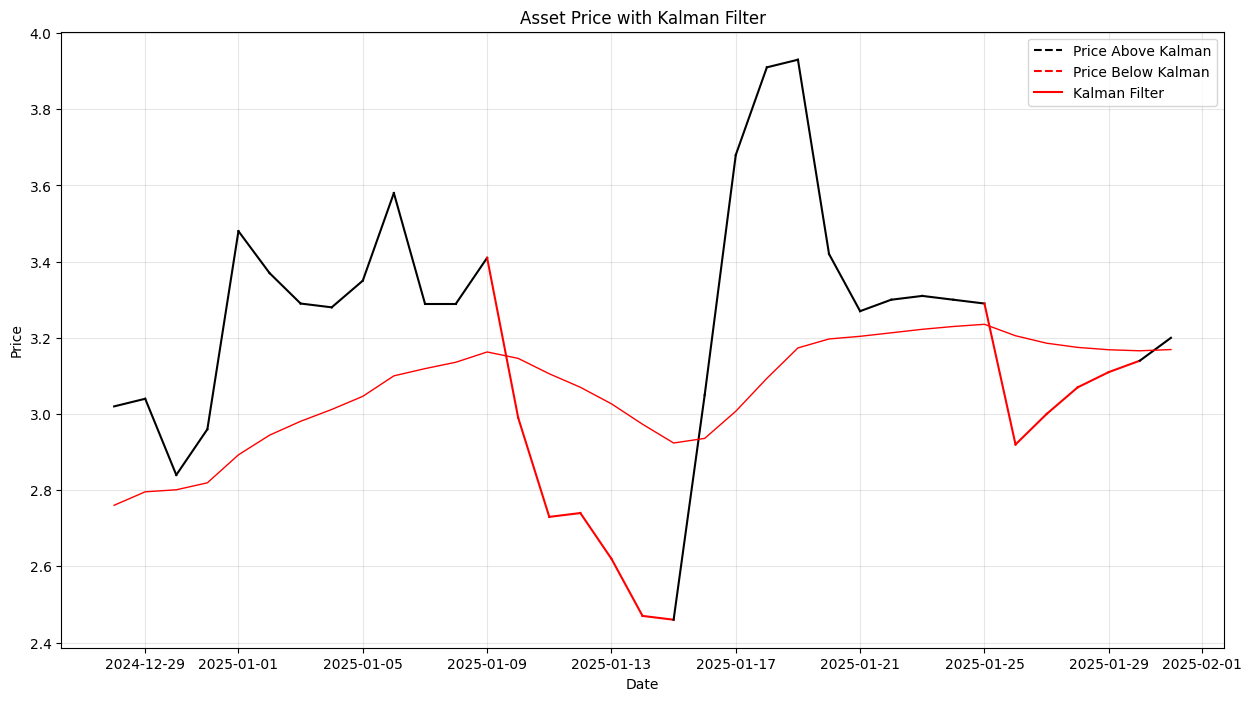

In [34]:
plot_kalman_results(df, start_date='2021-01-01', end_date='2025-1-31')

In [35]:
def split_date_wise(data, 
                    embargo_percent=0.01, 
                    train_start_date=None,
                    train_end_date=None):
    
    #throw error if data in improper form
    if isinstance(data, pd.DataFrame) == False or 'Date' not in data:
        raise ValueError("""Data must be of type pd.DataFrame and contain a 
                         'date' column.""")
       
    #handle no dates given
    if train_start_date == None and train_end_date == None:
        raise ValueError("""At least one of train_start_date and 
                         train_end_date params must be given an argument.""")
 
    #handle end date given but no start
    if train_end_date != None and train_start_date == None:
        train_start_date = data['Date'][0]
 
    #handle start date given but no end
    if train_start_date != None and train_end_date == None:
        raise ValueError('end_date must be given.')
     
    #find start index
    #consider forcing start date to nearest trade day if non-trading day given
    start_index = -1
    for i in range(len(data)):    
        if data['Date'][i] == pd.to_datetime(train_start_date):
            start_index = i 
    
    #raise error if day train_start_date not in data
    if start_index < 0:
        raise ValueError('train_start_date of: ' + train_start_date + 
                         ' not in data.'
                         +' Make sure given date is trading day.')
    
    #find end index
    end_index = -1
    for i in range(len(data)):
        if data['Date'][i] == pd.to_datetime(train_end_date):
            end_index = i
    
    #throw error if day train_start_date not in data
    if end_index < 0:
        raise ValueError(
            'train_end_date of: ' + train_end_date + ' not in data.'
                         +' Make sure given date is trading day.')
    
    #set train, test and embargo set    
    train = data[start_index:end_index+1]
    test = data[round((end_index+1)+(embargo_percent*len(data))):]
    embargo = data[end_index+1:round(end_index+(embargo_percent*len(data))+1)]
    
    #throw error if test set empty
    if len(test) == 0:
        raise ValueError(
            'No data in test set, reduce embargo size or date range.')
    
    #warn if embargo length short
    if len(embargo) < 5:
        import warnings
        warnings.warn("""<5 embargoed data points means data the model was
                      trained on is likely to leak into test set.""")
      
    return train, embargo, test

def split_rand(data, train_percent):

    train = data[np.random.rand(len(data)) < 0.8]
    test = data[~np.random.rand(len(data)) < 0.8]
    
    return train, test

In [36]:
df.reset_index(inplace=True)
train, embargo, test = split_date_wise(df,
                                     embargo_percent=0,
                                     train_start_date=None,
                                     train_end_date='2024-12-31')

/var/folders/p_/s5m9ntfs6rs0ntx6z7795qgrsb4pj6/T/ipykernel_80164/1583098882.py:62: UserWarning:

<5 embargoed data points means data the model was
                      trained on is likely to leak into test set.



## Long Only Trades

In [37]:
def transact_at_open(df):
    """
    Creates trading signals based on price position relative to Kalman smooth line:
    - Long when Close price is above Kalman smooth
    - Flat when Close price is equal to or below Kalman smooth
    
    Parameters:
        df : pd.DataFrame
            DataFrame containing at least 'Close', 'Open', and 'kalman_smooth' columns
    
    Returns:
        result : pd.DataFrame
            A copy of the input df with additional columns for signal generation and returns
    """
    # Make a copy of input data
    result = df.copy()
    
    # Generate state based on Close price position relative to Kalman smooth
    result['state'] = np.where(result['Close'] > result['kalman_close'], 'Long', 'Flat')
    
    # Shift the signal by 1 day (so you trade at today's open based on yesterday's close)
    result['signal'] = result['state'].shift(1)
    
    # Generate position: 1 for Long, 0 for Flat
    result['position'] = np.where(result['signal'] == 'Long', 1, 0)
    
    # Calculate returns
    result['next_open'] = result['Open'].shift(-1)
    result['open_return'] = result['next_open'] / result['Open'] - 1
    result['open_return'] = result['open_return'].fillna(0)
    
    # Calculate strategy returns
    result['strategy_return'] = result['position'] * result['open_return']
    
    # Mark trades (changes in position)
    result['trade'] = (result['signal'] != result['signal'].shift(1)).astype(int)
    
    # Calculate cumulative returns
    result['cum_strategy_return'] = (1 + result['strategy_return']).cumprod() - 1
    result['cum_buy_hold_return'] = (1 + result['open_return']).cumprod() - 1
    
    # Clean up intermediate columns
    result.drop(['next_open'], axis=1, inplace=True)
    
    return result

In [38]:
# Assuming df has Close, Open, and kalman_smooth columns
result = transact_at_open(test)

In [39]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_kalman_trading_results(df):
    """
    Given a DataFrame (such as that returned by transact_at_open()) that includes:
      - Date (as index or column)
      - 'Close': Close prices
      - 'kalman_close': Kalman filtered prices
      - 'cum_buy_hold_return': cumulative return from buying and holding
      - 'cum_strategy_return': cumulative return from the Kalman-based strategy
      - 'position': trading position (1 for long, 0 for flat)
    """
    
    # Ensure Date is datetime and properly set
    if 'Date' in df.columns:
        df = df.set_index('Date')
    
    # Create figure with secondary y-axis
    fig = make_subplots(rows=2, cols=1, 
                       shared_xaxes=True,
                       vertical_spacing=0.1,
                       row_heights=[0.7, 0.3])

    # Top Panel: Returns and Prices
    # Plot Close prices colored by position
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['Close'],
            mode='lines',
            name='Close Price',
            line=dict(
                color='black',
                width=1
            )
        ),
        row=1, col=1
    )
    
    # Plot Kalman smooth line
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['kalman_close'],
            mode='lines',
            name='Kalman Smooth',
            line=dict(color='blue', width=1)
        ),
        row=1, col=1
    )
    
    # Bottom Panel: Strategy Performance
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['cum_strategy_return'],
            mode='lines',
            name='Strategy Returns',
            line=dict(color='green', width=2)
        ),
        row=2, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=df.index,
            y=df['cum_buy_hold_return'],
            mode='lines',
            name='Buy & Hold Returns',
            line=dict(color='gray', width=2)
        ),
        row=2, col=1
    )
    
    # Update layout
    fig.update_layout(
        title='Kalman-Based Trading Strategy Analysis',
        template='plotly_white',
        height=800,
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Update y-axes labels
    fig.update_yaxes(title_text="Price", row=1, col=1)
    fig.update_yaxes(title_text="Cumulative Return", row=2, col=1)
    
    # Update x-axis label
    fig.update_xaxes(title_text="Date", row=2, col=1)
    
    # Show the plot
    fig.show()

def calculate_performance_metrics(df):
    """
    Calculate key performance metrics for the trading strategy.
    """
    # Daily returns
    strategy_daily_returns = df['strategy_return']
    bh_daily_returns = df['open_return']
    
    # Annualized metrics (assuming 252 trading days)
    ann_factor = 252
    
    # Returns
    strategy_total_return = df['cum_strategy_return'].iloc[-1]
    bh_total_return = df['cum_buy_hold_return'].iloc[-1]
    
    strategy_ann_return = (1 + strategy_total_return) ** (ann_factor/len(df)) - 1
    bh_ann_return = (1 + bh_total_return) ** (ann_factor/len(df)) - 1
    
    # Volatility
    strategy_vol = strategy_daily_returns.std() * np.sqrt(ann_factor)
    bh_vol = bh_daily_returns.std() * np.sqrt(ann_factor)
    
    # Sharpe Ratio (assuming 0% risk-free rate for simplicity)
    strategy_sharpe = strategy_ann_return / strategy_vol if strategy_vol != 0 else 0
    bh_sharpe = bh_ann_return / bh_vol if bh_vol != 0 else 0
    
    # Maximum Drawdown
    strategy_cum_returns = (1 + df['cum_strategy_return'])
    bh_cum_returns = (1 + df['cum_buy_hold_return'])
    
    strategy_running_max = strategy_cum_returns.expanding().max()
    bh_running_max = bh_cum_returns.expanding().max()
    
    strategy_drawdown = (strategy_cum_returns - strategy_running_max) / strategy_running_max
    bh_drawdown = (bh_cum_returns - bh_running_max) / bh_running_max
    
    strategy_max_drawdown = strategy_drawdown.min()
    bh_max_drawdown = bh_drawdown.min()
    
    # Number of trades
    n_trades = df['trade'].sum()
    
    # Win rate
    winning_trades = (df['strategy_return'] > 0).sum()
    win_rate = winning_trades / n_trades if n_trades > 0 else 0
    
    metrics = {
        'Total Return': [strategy_total_return, bh_total_return],
        'Annualized Return': [strategy_ann_return, bh_ann_return],
        'Annualized Volatility': [strategy_vol, bh_vol],
        'Sharpe Ratio': [strategy_sharpe, bh_sharpe],
        'Maximum Drawdown': [strategy_max_drawdown, bh_max_drawdown],
        'Number of Trades': [n_trades, 'N/A'],
        'Win Rate': [win_rate, 'N/A']
    }
    
    # Create DataFrame and format
    metrics_df = pd.DataFrame(metrics, index=['Strategy', 'Buy & Hold']).T
    
    # Format percentages
    for col in metrics_df.columns:
        metrics_df[col] = metrics_df[col].apply(lambda x: 
            f'{x:.2%}' if isinstance(x, (float, int)) and 'Number' not in metrics_df.index[metrics_df[col] == x] 
            else x)
    
    return metrics_df

    

In [40]:
# Assuming df has all required columns from transact_at_open()
plot_kalman_trading_results(result)
performance_table = calculate_performance_metrics(result)
print(performance_table)

                      Strategy Buy & Hold
Total Return           -19.59%    -26.26%
Annualized Return      -68.94%    -80.48%
Annualized Volatility   75.98%    128.40%
Sharpe Ratio           -90.74%    -62.68%
Maximum Drawdown       -26.91%    -55.10%
Number of Trades             7        N/A
Win Rate               114.29%        N/A
